# MediaPileチュートリアル

## 1. MediaPipeのインストール
まずは、MediaPipeを使うために自身のGoogle Colabにインストールする必要があります。
下のブロックをただ実行すればOKです。

※余談：!がついたものはPythonコードではなく、ターミナルの指示として認識されます。

Successfully installed ... となれば成功

In [1]:
# !pip install mediapipe opencv-python-headless

次に、必要なAIモデルをダウンロードしましょう。これも下のブロックをただ実行すればOKです。

モデルダウンロード完了！となれば成功

In [2]:
# !wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task -O pose_landmarker.task
# print("モデルダウンロード完了！")

In [3]:
from pathlib import Path
model_path = Path("pose_landmarker.task")

print(f"モデルファイル: {model_path.resolve()}")

モデルファイル: /Users/suzukiakiramuki/school/programming_exercise/mediapipe/pose_landmarker.task


次に、計算に必要なライブラリをインストールしましょう。
C言語で言うstring.hみたいなものです。

インポート成功！となれば成功

In [4]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import threading
import time
import math
from IPython.display import display

print("インポート成功！")

インポート成功！


最後に、ポーズ検出器を定義します。これも下のブロックを実行すればOKです。

検出器の準備完了！となれば成功

In [5]:
if not model_path.exists():
    raise FileNotFoundError(f"モデルファイルが見つかりません: {model_path.resolve()}")

base_options = python.BaseOptions(model_asset_path=str(model_path.resolve()))
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False
)
detector = vision.PoseLandmarker.create_from_options(options)

print("検出器の準備完了！")

検出器の準備完了！


I0000 00:00:1776218179.529040 2263093 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776218179.570470 2263094 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776218179.575645 2263094 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 2. MediaPileを理解しよう

MediaPipeは体の33箇所の関節位置（ランドマーク） を座標として取得します。<br>
主なランドマーク番号<br>
0: 鼻<br>
11: 左肩         12: 右肩<br>
13: 左肘         14: 右肘<br>
15: 左手首       16: 右手首<br>
23: 左腰         24: 右腰<br>
25: 左膝         26: 右膝<br>
27: 左足首       28: 右足首<br>

📌 LEFT / RIGHT は「カメラに映っている人から見た」左右（鏡と逆）
<br><br>
**座標の読み方**<br>
x 横位置（左→右）0.0〜1.0<br>
y 縦位置（上→下）0.0〜1.0<br>

⚠️ y は下に行くほど大きくなります。
「手首のy < 肩のy」の場合、手が肩より上にある

## 3. 骨格描画・ポーズ判定の関数を定義しよう

どの点とどの点をつなぐか定義します。とりあえずそのまま実行でOKです。

骨格描画関数の定義完了！となれば成功

In [6]:
# 骨格の接続定義（どの点とどの点を線でつなぐか）
POSE_CONNECTIONS = [
    (11, 12),           # 左肩 ↔ 右肩
    (11, 13), (13, 15), # 左肩 → 左肘 → 左手首
    (12, 14), (14, 16), # 右肩 → 右肘 → 右手首
    (11, 23), (12, 24), # 肩 → 腰
    (23, 24),           # 左腰 ↔ 右腰
    (23, 25), (25, 27), # 左腰 → 左膝 → 左足首
    (24, 26), (26, 28), # 右腰 → 右膝 → 右足首
]

def draw_bones(image, pose_landmarks):
    """骨格（ボーン）と関節点を画像に描画する"""
    h, w, _ = image.shape

    # 骨格の線を描画
    for start_idx, end_idx in POSE_CONNECTIONS:
        start = pose_landmarks[start_idx]
        end   = pose_landmarks[end_idx]
        sx, sy = int(start.x * w), int(start.y * h)
        ex, ey = int(end.x * w),   int(end.y * h)
        cv2.line(image, (sx, sy), (ex, ey), (255, 255, 255), 2)

    # 各関節の点を描画
    for lm in pose_landmarks:
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(image, (cx, cy), 5, (0, 255, 0), -1)

    return image

print("骨格描画関数の定義完了！")

骨格描画関数の定義完了！


## 4. 読み込んだ画像に骨格を描画しよう
まずは、人体が写っている画像を用意して、`photos/image.png` として保存しよう。

Colabの左側にあるフォルダアイコン<br>
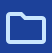<br>
をクリックし、アップロードボタン
<br>
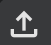<br>
からpose.jpgをアップロード。

アップロードが完了したら、下のブロックを実行しましょう。

画像内に骨格が表示されたら成功。

In [7]:
def draw_landmarks(image, result):
    annotated = image.copy()

    for pose_landmarks in result.pose_landmarks:
        draw_bones(annotated, pose_landmarks)

    return annotated

W0000 00:00:1776218179.640629 2263097 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


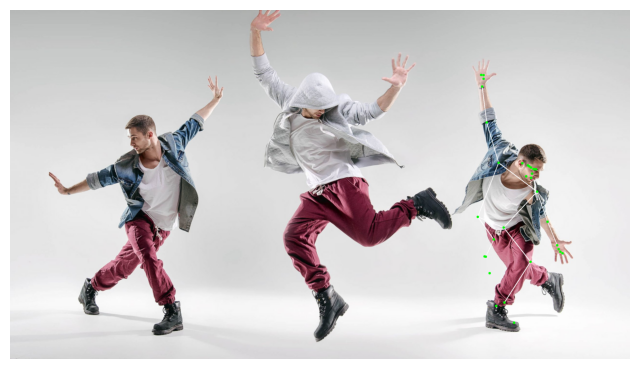

検出成功！1人のポーズを検出しました


In [8]:
image_path = Path("photos/image.png")
image_cv = cv2.imread(str(image_path))

if image_cv is None:
    raise FileNotFoundError(f"画像を読めません : {image_path.resolve()}")

image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

# MediaPipe形式に変換して検出
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
result = detector.detect(mp_image)

if result.pose_landmarks:
    annotated = draw_landmarks(image_cv, result)
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
    print(f"検出成功！{len(result.pose_landmarks)}人のポーズを検出しました")
else:
    print("ポーズが検出できませんでした")

## (重要)　5.ポーズ判定を定義しよう

ここで、どんなポーズの時に、どんな処理をするか定義します。
初期では
- 15（左手首）・16（右手首）・11（左肩）・12（右肩）の座標を取得　→ `pose_landmarks[15]`など
- 左手が上がっていることを`left_up  = left_wrist.y  < left_shoulder`　で確認
- 右手が上がっていることを`right_up = right_wrist.y < right_shoulder.y`で確認

- if文で片手、両手が上がった時の表示メッセージを定義
<br>しています。
<br><br>
下のブロックを実行しましょう。
ポーズ判定関数の定義完了！となれば成功です。

In [9]:
def judge_pose(image, pose_landmarks, pose_world_landmarks=None):
    """
    参考画像に近いポーズを含む複数のポーズを判定し、
    認識したポーズ名を返す。
    """
    h, w, _ = image.shape

    nose = pose_landmarks[0]
    left_shoulder = pose_landmarks[11]
    right_shoulder = pose_landmarks[12]
    left_elbow = pose_landmarks[13]
    right_elbow = pose_landmarks[14]
    left_wrist = pose_landmarks[15]
    right_wrist = pose_landmarks[16]

    wrist_distance_m = None
    marugoto = False
    if pose_world_landmarks is not None:
        left_wrist_world = pose_world_landmarks[15]
        right_wrist_world = pose_world_landmarks[16]
        wrist_distance_m = math.sqrt(
            (left_wrist_world.x - right_wrist_world.x) ** 3 +
            (left_wrist_world.y - right_wrist_world.y) ** 3 +
            (left_wrist_world.z - right_wrist_world.z) ** 3
        )
        marugoto = wrist_distance_m <= 0.20

    left_arm_above_head = (
        left_wrist.y < nose.y and
        left_elbow.y < left_shoulder.y
    )

    right_arm_above_head = (
        right_wrist.y < nose.y and
        right_elbow.y < right_shoulder.y
    )

    left_arm_across_face = (
        abs(left_wrist.y - nose.y) < 0.18 and
        abs(left_elbow.y - nose.y) < 0.22 and
        left_wrist.x > left_shoulder.x
    )

    right_arm_across_face = (
        abs(right_wrist.y - nose.y) < 0.18 and
        abs(right_elbow.y - nose.y) < 0.22 and
        right_wrist.x < right_shoulder.x
    )

    left_bent = abs(left_wrist.x - left_elbow.x) > 0.05
    right_bent = abs(right_wrist.x - right_elbow.x) > 0.05

    image_pose = (
        (left_arm_above_head and right_arm_across_face and left_bent and right_bent) or
        (right_arm_above_head and left_arm_across_face and left_bent and right_bent)
    )

    if marugoto:
        pose_key = "MARUGOTO"
        label = "MARUGOTO"
        color = (0, 255, 0)
    elif image_pose:
        pose_key = "IMAGE_POSE"
        label = "IMAGE POSE!"
        color = (255, 255, 255)
    elif left_arm_above_head:
        pose_key = "LEFT_ARM_ABOVE_HEAD"
        label = "LEFT ARM ABOVE HEAD"
        color = (255, 255, 128)
    elif right_arm_above_head:
        pose_key = "RIGHT_ARM_ABOVE_HEAD"
        label = "RIGHT ARM ABOVE HEAD"
        color = (255, 255, 0)
    elif left_arm_across_face:
        pose_key = "LEFT_ARM_ACROSS_FACE"
        label = "LEFT ARM ACROSS FACE"
        color = (255, 128, 255)
    elif right_arm_across_face:
        pose_key = "RIGHT_ARM_ACROSS_FACE"
        label = "RIGHT ARM ACROSS FACE"
        color = (255, 128, 128)
    elif left_bent:
        pose_key = "LEFT_BENT"
        label = "LEFT BENT"
        color = (255, 128, 0)
    elif right_bent:
        pose_key = "RIGHT_BENT"
        label = "RIGHT BENT"
        color = (255, 0, 255)
    else:
        pose_key = None
        label = "Keep Trying..."
        color = (0, 0, 255)

    chest_x = int((left_shoulder.x + right_shoulder.x) / 2 * w) - 120
    chest_y = int(min(left_shoulder.y, right_shoulder.y) * h) - 20

    cv2.putText(
        image,
        label,
        (max(chest_x, 10), max(chest_y, 40)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        color,
        3,
    )

    if wrist_distance_m is not None:
        cv2.putText(
            image,
            f'PALM DIST: {wrist_distance_m:.2f}m',
            (20, h - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2,
        )

    return pose_key

print("ポーズ判定関数の定義完了！")


ポーズ判定関数の定義完了！


## 6. リアルタイムストリーミングを起動しよう
ここが今日のメインです。ローカル PC のカメラ映像をリアルタイムで処理して表示します。

そのままコピーして実行してください。

**実行後の流れ**：

- 最初の数秒でカメラ初期化が行われ、状態メッセージが表示される
- その後、ウィジェットに映像が表示され始める
- 体全体が映るようにカメラから離れる（1〜2m推奨）
- 停止するときは 「⏹ ストリーミング停止」 ボタンを押す

In [10]:
stream_img = widgets.Image(format='jpeg', width='960')
display(stream_img)

combo_sequence = [
    "LEFT_ARM_ABOVE_HEAD",
    "RIGHT_ARM_ACROSS_FACE",
    "IMAGE_POSE",
]

combo_state = {
    "index": 0,
    "last_pose": None,
    "stable_frames": 0,
    "last_step_time": 0.0,
    "message": f"COMBO: 1/{len(combo_sequence)}  {combo_sequence[0]}",
}

def process_frame(image_cv):
    image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    result = detector.detect(mp_image)
    current_pose = None

    if result.pose_landmarks:
        landmarks = result.pose_landmarks[0]
        draw_bones(image_cv, landmarks)
        world_landmarks = result.pose_world_landmarks[0] if result.pose_world_landmarks else None
        current_pose = judge_pose(image_cv, landmarks, world_landmarks)

    if current_pose is not None and current_pose == combo_state["last_pose"]:
        combo_state["stable_frames"] += 1
    elif current_pose is not None:
        combo_state["last_pose"] = current_pose
        combo_state["stable_frames"] = 1
    else:
        combo_state["last_pose"] = None
        combo_state["stable_frames"] = 0

    now = time.time()
    if combo_state["index"] > 0 and now - combo_state["last_step_time"] > 3.0:
        combo_state["index"] = 0
        combo_state["message"] = f"COMBO RESET: 1/{len(combo_sequence)}  {combo_sequence[0]}"

    if current_pose is not None and combo_state["stable_frames"] >= 3:
        expected_pose = combo_sequence[combo_state["index"]]

        if current_pose == expected_pose:
            combo_state["index"] += 1
            combo_state["last_step_time"] = now
            combo_state["last_pose"] = None
            combo_state["stable_frames"] = 0

            if combo_state["index"] == len(combo_sequence):
                combo_state["message"] = "COMBO SUCCESS!"
                combo_state["index"] = 0
            else:
                next_pose = combo_sequence[combo_state['index']]
                combo_state["message"] = f"COMBO: {combo_state['index'] + 1}/{len(combo_sequence)}  {next_pose}"
        elif current_pose == combo_sequence[0]:
            combo_state["index"] = 1
            combo_state["last_step_time"] = now
            combo_state["last_pose"] = None
            combo_state["stable_frames"] = 0
            next_pose = combo_sequence[combo_state['index']]
            combo_state["message"] = f"COMBO: {combo_state['index'] + 1}/{len(combo_sequence)}  {next_pose}"
        else:
            combo_state["index"] = 0
            combo_state["last_pose"] = None
            combo_state["stable_frames"] = 0
            combo_state["message"] = f"WRONG ORDER: 1/{len(combo_sequence)}  {combo_sequence[0]}"

    cv2.putText(
        image_cv,
        combo_state["message"],
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 255, 0),
        2,
    )

    return image_cv

def open_camera(index=0):
    cap = cv2.VideoCapture(index)
    if cap.isOpened():
        return cap, 'Default'
    cap.release()

    if hasattr(cv2, 'CAP_AVFOUNDATION'):
        cap = cv2.VideoCapture(index, cv2.CAP_AVFOUNDATION)
        if cap.isOpened():
            return cap, 'AVFoundation'
        cap.release()

    return None, None

cap, backend_name = open_camera(0)
if cap is None:
    raise RuntimeError('カメラを開けませんでした。macOS の場合は Terminal / VS Code / Jupyter にカメラ権限を付与してください。')

print(f'カメラ起動: {backend_name}')
print('セルの実行を停止すると終了します')

try:
    while True:
        ok, frame = cap.read()
        if not ok:
            print('フレーム取得に失敗しました')
            break

        frame = process_frame(frame)
        ok, buf = cv2.imencode('.jpg', frame, [cv2.IMWRITE_JPEG_QUALITY, 80])
        if not ok:
            print('画像のエンコードに失敗しました')
            break

        stream_img.value = buf.tobytes()
        time.sleep(0.05)
except KeyboardInterrupt:
    print('ストリーミングを停止しました')
finally:
    cap.release()


Image(value=b'', format='jpeg', width='960')

カメラ起動: Default
セルの実行を停止すると終了します


ValueError: math domain error